# 00 · Training protocol

*Task 00 of the rebuilt mRNN analysis. Everything downstream imports the recipe this
notebook selects.*

**The problem.** Every fit in the legacy tree was trained with an optimiser that never
settled. Loss trajectories spike by one to two orders of magnitude right through to the
final iteration, and only 23% of saved checkpoints sit within 5% of the lowest loss
their own run reached.

That is not a cosmetic complaint. A spiky trajectory means the run never converged, so
its best iterate is the luckiest point on a jittery walk — and different seeds land at
different lucky points. **That is a live alternative explanation for the central finding
of the legacy analysis**, which is that independently fitted networks reproduce the data
equally well while routing their inter-regional currents differently. Until the fitting
is stable, we cannot tell a real property of the model class from optimiser noise.

**What this notebook does.**

| Section | |
|---|---|
| 1 | The problem, measured |
| 2 | Diagnosis — three things the spikes are *not*, and the one thing they are |
| 3 | A completed pilot: what a decaying learning rate already buys |
| 4 | The sweep design, and the bar it has to clear |
| 5 | Run state, and submission (off by default) |
| 6 | Result and selection |
| 7 | Reconstruction quality — does a good loss mean a faithful trace? |

**Nothing here submits a job unless you set `SUBMIT = True` in Section 5.** Every other
cell reads what is already on disk and is safe to re-run at any time.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_protocol as protocol
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_protocol as viz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings,
    apply_thesis_plot_style,
    figure_to_png_bytes,
    save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
MRNN_CFG_PATH = repo_root / "configs" / "ephys_fixation_mrnn.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

LEGACY_SCRATCH = syn.resolve_scratch_root(DATASET_CFG_PATH)
TASK_ROOT = protocol.resolve_chapter_root(DATASET_CFG_PATH, task="00_training_protocol")
PILOT_ROOT = TASK_ROOT / "pilot_lr3e4"
SWEEP_ROOT = TASK_ROOT / "sweep"
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="00_training_protocol")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

#: Iterations per sweep cell. The pilot ran 50,000; the sweep runs 100,000 so that a
#: configuration has to demonstrate it is *converging*, not merely quiet at the point we
#: stopped looking. It also changes the cosine trade-off in the sweep's favour: the
#: schedule is defined over the whole run, so doubling the budget doubles the time spent
#: near the peak rate before annealing begins.
SWEEP_EPOCHS = 100_000
#: Three seeds is a screen, not an estimate: it is enough to eliminate configurations
#: that are unstable, and the finalists get a proper multi-seed run afterwards.
SWEEP_SEEDS = 3


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


print("legacy runs :", LEGACY_SCRATCH)
print("task root   :", TASK_ROOT)
print("figures     :", FIGURE_DIR)

legacy runs : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch
task root   : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/chapter/00_training_protocol
figures     : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/00_training_protocol


## 1. The problem, measured

Every legacy run with a usable loss history, scored for two things: how often the loss
jumps upward by more than half a decade, and how far the saved final iterate sits above
the best one the run reached.

In [2]:
# Cached: reading settings out of ~270 legacy checkpoints takes minutes, and this
# notebook is meant to be re-run often while a sweep progresses. Pass refresh=True if
# the legacy tree ever changes.
survey = protocol.survey_legacy_instability(
    LEGACY_SCRATCH, cache_path=TASK_ROOT / "_diagnostics" / "legacy_instability_survey.csv"
)

spike_positions = np.concatenate([
    protocol.spike_positions(pd.read_csv(Path(LEGACY_SCRATCH) / run / "history.csv")["loss"].to_numpy(float))
    for run in survey.loc[survey["iterations"] >= 20_000, "run"]
])

display(Markdown(
    f"**{len(survey)} runs** with at least 5,000 iterations. "
    f"Median spike rate **{survey['spikes_per_10k'].median():.2f} per 10,000 iterations**; "
    f"only **{100 * survey['final_is_best'].mean():.0f}%** of runs end within 1% of their own best loss. "
    f"Pooling the {len(spike_positions):,} spikes from the long runs, "
    f"**{100 * np.mean(spike_positions > 0.5):.0f}%** occur in the second half of training — "
    f"so this is a persistent instability, not a warm-up artefact that training outgrows."
))

**271 runs** with at least 5,000 iterations. Median spike rate **0.40 per 10,000 iterations**; only **10%** of runs end within 1% of their own best loss. Pooling the 1,293 spikes from the long runs, **49%** occur in the second half of training — so this is a persistent instability, not a warm-up artefact that training outgrows.

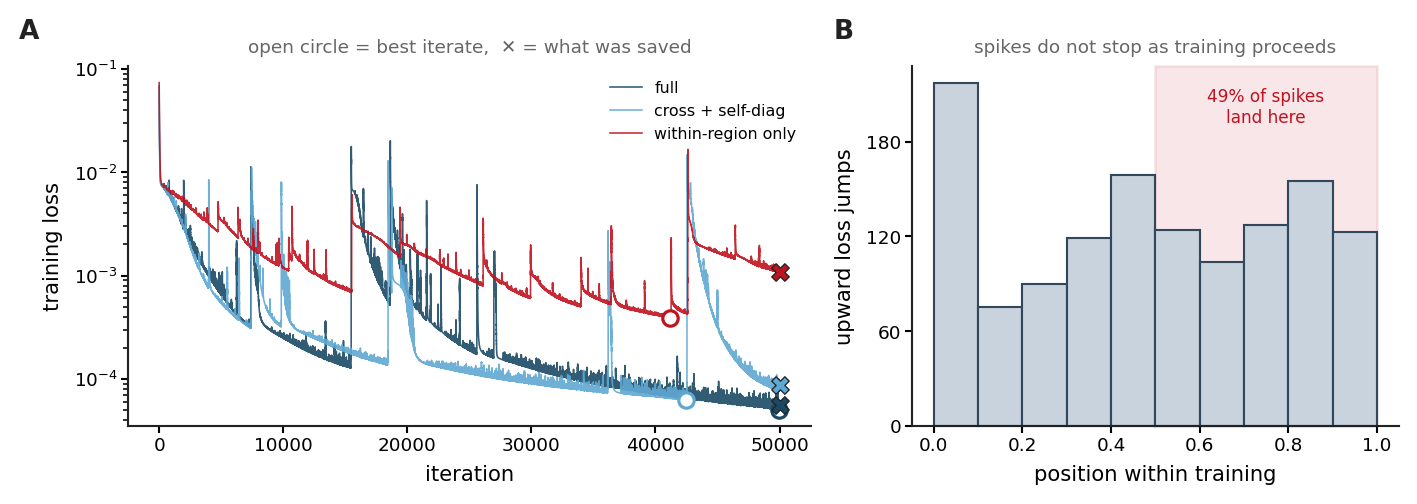

In [3]:
example_runs = {
    "full": "cca_42pc_tanh_h50_full",
    "cross + self-diag": "cca_42pc_tanh_h50_cross_region_with_self_diagonal",
    "within-region only": "cca_42pc_tanh_h50_within_region",
}
trajectories = {
    label: pd.read_csv(Path(LEGACY_SCRATCH) / run / "history.csv")["loss"].to_numpy(float)
    for label, run in example_runs.items()
}
show(viz.plot_instability_problem(trajectories, spike_positions), "fig01_the_problem")

**Figure 1.** (A) The three runs the legacy architecture comparison rests on. Note
which one is furthest from its own best: `within_region`, at 2.78× — the architecture the
comparison concludes against. (B) Spike position pooled over every long run.

## 2. Diagnosis

Three explanations can be ruled out before any tuning.

### 2a. It is not sampling noise

Three conditions, trained full-batch every iteration, with input and activation noise both
at zero. The loss is a deterministic function of the parameters, so an upward jump is the
optimiser **stepping uphill on a fixed landscape** — not variance between batches. That
matters because it rules out the usual remedies (larger batches, averaging) and rules in
step-size remedies.

In [4]:
from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_training import (
    load_fixation_mrnn_config,
    settings_from_config,
)
from dataclasses import replace

base_settings = replace(
    settings_from_config(load_fixation_mrnn_config(MRNN_CFG_PATH)),
    **protocol.PROTOCOL_ARCHITECTURE,
    activation="tanh",
    spectral_radius=1.1,
    lr=1e-3,
    device="cpu",
)
display(pd.Series(protocol.objective_is_deterministic(base_settings), name="objective").to_frame())

,objective
batch_size,3
full_batch,True
input_noise,0.0
activation_noise,0.0
deterministic,True


### 2b. It is not exploding gradients, and clipping was never doing anything

`clip_grad_norm_` returns the *pre-clip* norm, so setting the threshold far above any
plausible value turns it into a measurement. The cell below trains briefly with clipping
effectively disabled and records the gradient norm at every step.

The result decides whether the historical clip value of 1.0 was ever a constraint. Adam
rescales each parameter by its own second moment, so the step size is set by the learning
rate rather than by gradient magnitude — a global norm clip only does anything on the
steps where the norm actually exceeds it.

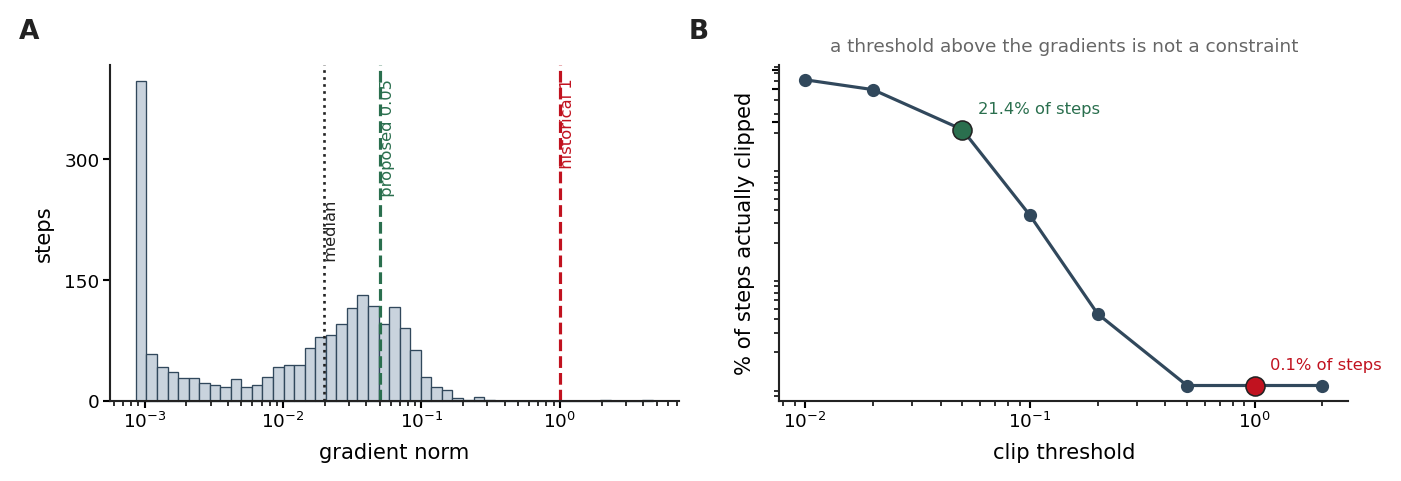

,clip_norm,fraction_of_steps_clipped
0,0.01,0.6095
1,0.02,0.4960
2,0.05,0.2145
3,0.10,0.0355
4,0.20,0.0045
5,0.50,0.0010
6,1.00,0.0010
7,2.00,0.0010


In [5]:
GRADIENT_PROBE_DIR = TASK_ROOT / "_diagnostics" / "gradient_norm_probe"
gradient_norms = protocol.measure_gradient_norms(
    base_settings, run_dir=GRADIENT_PROBE_DIR, iterations=2000, seed=31,
    cache_path=TASK_ROOT / "_diagnostics" / "gradient_norm_probe.csv",
)
binding = protocol.clip_threshold_binding_rate(
    gradient_norms, thresholds=[0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
)
show(viz.plot_gradient_norm_diagnosis(gradient_norms, binding), "fig02_gradient_norms")
display(binding.round(4))

In [6]:
values = gradient_norms["gradient_norm"]
historical = float(binding.loc[binding["clip_norm"] == 1.0, "fraction_of_steps_clipped"].iloc[0])
proposed = float(binding.loc[binding["clip_norm"] == 0.05, "fraction_of_steps_clipped"].iloc[0])

display(Markdown(
    f"Gradient norms have median **{values.median():.3f}** and 90th percentile "
    f"**{values.quantile(0.9):.3f}**. The historical clip threshold of 1.0 therefore binds on "
    f"**{100 * historical:.1f}% of steps** — it has never been a constraint, which is why turning "
    f"it on changed nothing in the legacy runs. A threshold of 0.05 binds on "
    f"**{100 * proposed:.0f}%** of steps and is the first value worth testing."
))

Gradient norms have median **0.020** and 90th percentile **0.073**. The historical clip threshold of 1.0 therefore binds on **0.1% of steps** — it has never been a constraint, which is why turning it on changed nothing in the legacy runs. A threshold of 0.05 binds on **21%** of steps and is the first value worth testing.

### 2c. What does move it: the learning rate

The legacy tree is an unplanned natural experiment spanning six learning rates. It cannot
separate confounded axes — the low-rate runs are also the `tanh` runs and the
low-spectral-radius runs — which is exactly what the sweep is for. What it can do is show
which axis moves the instability at all, and set the sweep's range.

,lr,n_runs,spikes_per_10k,median_final_over_best,pct_final_is_best
0,0.000,4,0.0,1.007,75.000
1,0.000,36,0.1,1.022,27.778
2,0.001,226,0.4,1.289,6.195
3,0.002,2,1.0,1.328,0.000
4,0.005,1,6.0,NaN,0.000
5,0.010,2,2.5,NaN,0.000


Clipping, held inside the homogeneous `lr=1e-3` + `softplus` block (`clip = -1` means none):

,clip,n_runs,spikes_per_10k,median_final_over_best
0,-1.0,119,0.4,1.251
1,1.0,106,0.5,1.364


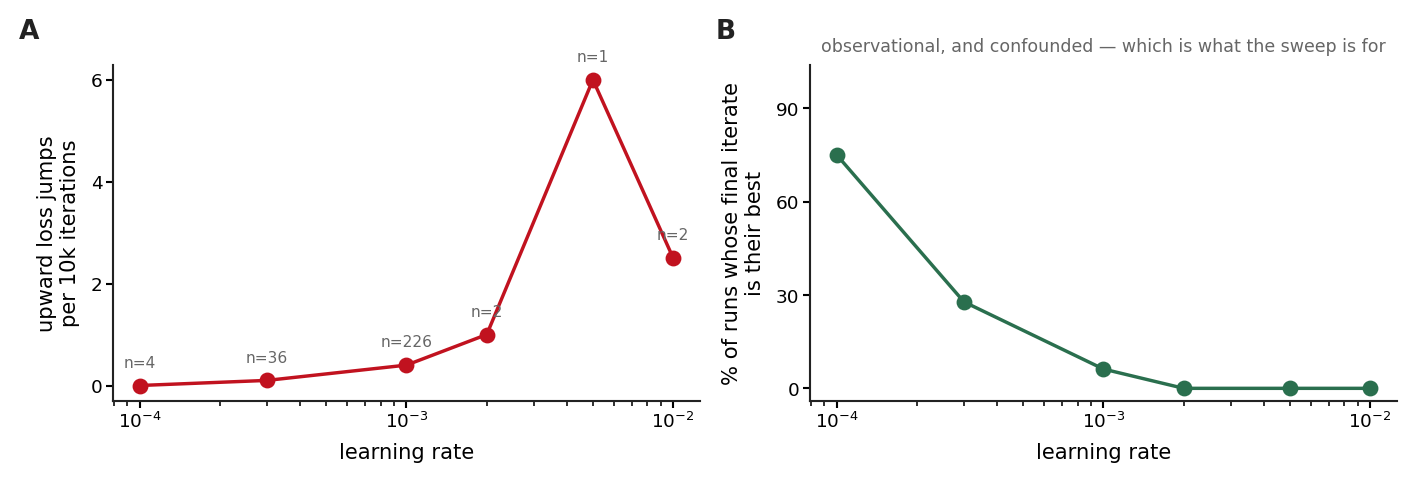

In [7]:
by_rate = (
    survey.groupby("lr")
    .agg(n_runs=("run", "size"),
         spikes_per_10k=("spikes_per_10k", "median"),
         median_final_over_best=("final_over_best", "median"),
         pct_final_is_best=("final_is_best", lambda v: 100 * v.mean()))
    .reset_index()
    .sort_values("lr")
)
display(by_rate.round(3))

by_clip = (
    survey[(survey["lr"] == 1e-3) & (survey["activation"] == "softplus")]
    .assign(clip=lambda d: d["gradient_clip_norm"].fillna(-1))
    .groupby("clip")
    .agg(n_runs=("run", "size"),
         spikes_per_10k=("spikes_per_10k", "median"),
         median_final_over_best=("final_over_best", "median"))
    .reset_index()
)
display(Markdown("Clipping, held inside the homogeneous `lr=1e-3` + `softplus` block (`clip = -1` means none):"))
display(by_clip.round(3))

show(viz.plot_legacy_learning_rate_survey(survey), "fig03_legacy_learning_rate")

## 3. A completed pilot

Twenty runs at `lr = 3e-4`, `tanh`, spectral radius 1.1, 50,000 iterations: a full
2 × 2 of schedule (constant, cosine) × clipping (none, 1.0), five shared seeds each.
Because the seeds are shared, the schedule comparison is paired.

In [8]:
pilot_configs = [
    protocol.ProtocolConfig(label=label, lr=3e-4, gradient_clip_norm=clip, lr_schedule=schedule)
    for label, clip, schedule in [
        ("lr0p0003_clipnone_constant", None, "constant"),
        ("lr0p0003_clipnone_cosine", None, "cosine"),
        ("lr0p0003_clip1_constant", 1.0, "constant"),
        ("lr0p0003_clip1_cosine", 1.0, "cosine"),
    ]
]
pilot_seeds = protocol.protocol_seeds(n_seeds=5)
pilot_inventory = protocol.index_protocol_runs(PILOT_ROOT, pilot_configs, pilot_seeds)
pilot_scores = protocol.configurations_meeting_bar(pilot_inventory)

pilot_per_seed = []
for _, run in pilot_inventory.iterrows():
    history_path = Path(run["run_dir"]) / "history.csv"
    if not history_path.exists():
        continue
    losses = pd.read_csv(history_path)["loss"].to_numpy(float)
    pilot_per_seed.append({
        "lr_schedule": run["lr_schedule"],
        "gradient_clip_norm": run["gradient_clip_norm"],
        "seed": run["seed"],
        "losses": losses,
        "best_loss": float(np.nanmin(losses)),
        **protocol.evaluate_convergence(losses),
    })
pilot_per_seed = pd.DataFrame(pilot_per_seed)

display(
    pilot_per_seed.groupby(["lr_schedule", "gradient_clip_norm"], dropna=False)
    .agg(n=("seed", "size"), max_late_spikes=("late_spikes", "max"),
         median_final_over_best=("final_over_best", "median"),
         worst_final_over_best=("final_over_best", "max"),
         median_best_loss=("best_loss", "median"))
    .round(5)
)

n  max_late_spikes  median_final_over_best  \
lr_schedule gradient_clip_norm                                               
constant    1.0                 5                2                 1.01797   
            NaN                 5                1                 1.00477   
cosine      1.0                 5                0                 1.00000   
            NaN                 5                0                 1.00000   

                                worst_final_over_best  median_best_loss  
lr_schedule gradient_clip_norm                                           
constant    1.0                               7.89716           0.00075  
            NaN                               1.01527           0.00091  
cosine      1.0                               1.00000           0.00115  
            NaN                               1.00000           0.00116

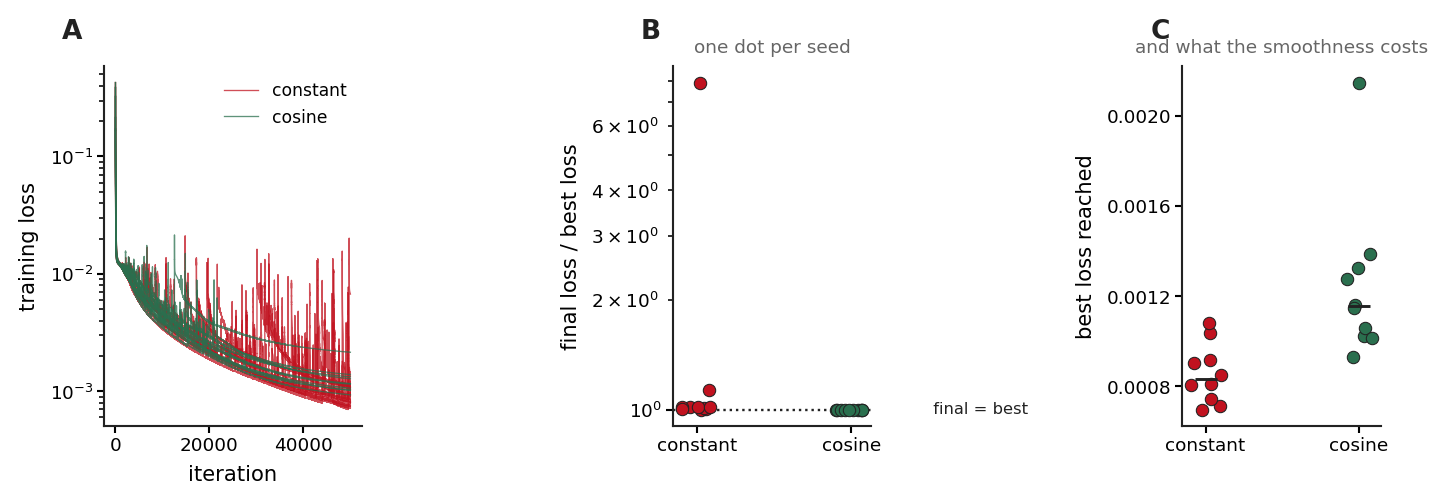

In [9]:
pilot_trajectories = {
    schedule: list(pilot_per_seed.loc[pilot_per_seed["lr_schedule"] == schedule, "losses"])
    for schedule in ("constant", "cosine")
}
show(viz.plot_pilot_schedule_comparison(pilot_per_seed, pilot_trajectories), "fig04_pilot_schedule")

In [10]:
cosine = pilot_per_seed[pilot_per_seed["lr_schedule"] == "cosine"]
constant = pilot_per_seed[pilot_per_seed["lr_schedule"] == "constant"]
cost = cosine["best_loss"].median() / constant["best_loss"].median()

display(Markdown(
    f"**A decaying learning rate solves the trustworthiness problem outright.** All "
    f"{len(cosine)} cosine runs end at `final / best = "
    f"{cosine['final_over_best'].max():.4f}` — the final iterate *is* the best iterate, on every "
    f"seed — with zero upward jumps in the second half of training. The constant-schedule runs "
    f"reach a median of {constant['final_over_best'].median():.3f} and a worst case of "
    f"**{constant['final_over_best'].max():.2f}×**.\n\n"
    f"**Clipping at 1.0 still does nothing**, now under a seed-matched design rather than "
    f"observationally: it changes neither the spike count nor the final-over-best ratio, and the "
    f"single worst run in the pilot is a *clipped* one. This is the control that closes Section 2b.\n\n"
    f"**But smoothness is not free.** The cosine runs reach a best loss "
    f"**{cost:.2f}×** that of the constant runs: decaying the rate also stops the search. At "
    f"`lr = 3e-4` over 50,000 iterations there is not enough budget to both explore and anneal.\n\n"
    f"That is the question the sweep has to answer — **not whether to decay the rate, but how high "
    f"a peak rate the decay can safely carry.**"
))

**A decaying learning rate solves the trustworthiness problem outright.** All 10 cosine runs end at `final / best = 1.0000` — the final iterate *is* the best iterate, on every seed — with zero upward jumps in the second half of training. The constant-schedule runs reach a median of 1.014 and a worst case of **7.90×**.

**Clipping at 1.0 still does nothing**, now under a seed-matched design rather than observationally: it changes neither the spike count nor the final-over-best ratio, and the single worst run in the pilot is a *clipped* one. This is the control that closes Section 2b.

**But smoothness is not free.** The cosine runs reach a best loss **1.39×** that of the constant runs: decaying the rate also stops the search. At `lr = 3e-4` over 50,000 iterations there is not enough budget to both explore and anneal.

That is the question the sweep has to answer — **not whether to decay the rate, but how high a peak rate the decay can safely carry.**

## 4. The sweep, and the bar it has to clear

### 4a. The bar, stated before the runs

Fixed here so the criterion cannot be reverse-engineered from whichever configuration
happens to win. A configuration is usable only if **every one of its seeds** shows:

- no upward loss jump larger than 0.5 decades in the **second half** of training, and
- a final iterate within **1%** of the best iterate.

Among the configurations that clear the bar, the one with the lowest median best loss is
selected. Fit is the tie-breaker, not the criterion — a configuration that fits
beautifully on some seeds and thrashes on others is useless for the multi-seed ensembles
this whole analysis depends on.

In [11]:
BAR = protocol.ConvergenceBar()
display(pd.Series(BAR.__dict__, name="convergence bar").to_frame())

,convergence bar
jump_threshold_log10,0.5
late_fraction,0.5
max_final_over_best,1.01
require_all_seeds,True


### 4b. What the two schedules are

**Constant** is what every legacy run used: the learning rate is set once and never
changes, so the optimiser takes the same-sized step at iteration 99,999 as at iteration 1.
Late in training, when the model is near a solution and the landscape is sharp, a step
that size keeps overshooting — which is exactly the spike pattern in Figure 4A, running
all the way to the end.

**Cosine** starts at the same peak rate and follows a half-cosine down to a floor
(here 1% of the peak) over the course of the run:

$$\eta(t)=\eta_{\min}+\tfrac{1}{2}\,(\eta_{\text{peak}}-\eta_{\min})\left(1+\cos\frac{\pi t}{T}\right)$$

It holds near the peak early, decays fastest in the middle, and flattens out near zero at
the end. By the last fifth of training the step is small enough that it *cannot* overshoot,
so the trajectory necessarily settles and the final iterate is the best one — which is why
Figure 4B collapses to exactly 1.000.

The cost is that time spent at a low rate is not time spent searching, which is why the
cosine runs in the pilot reached a worse best loss at the same peak rate. **That is also
why this sweep runs 100,000 iterations rather than the pilot's 50,000**: the schedule is
defined over the whole run, so a longer budget buys more time near the peak before
annealing begins, and it forces each configuration to show it is converging rather than
merely quiet at the point we stopped looking.

### 4c. The design

One factorial plus two control arms, rather than a full product over every axis — most
of a full product would be spent re-answering what Sections 2 and 3 have settled.

- **Main arm** — peak learning rate × initial spectral radius, on cosine with no
  clipping. A spectral radius above ~1 is what sharpens the landscape through 100
  recurrent steps, so 0.9 and 1.1 bracket the edge of chaos.
- **Schedule control** — the same rates on a constant schedule, so the cosine result is
  demonstrated inside this sweep and not imported from the pilot.
- **Clipping control** — the same rates with a clip norm of **0.05**, the first threshold
  Section 2b shows actually binds.

**The activation is not swept.** `tanh` is fixed on a reasoned prior rather than a
measured one, and the chapter should say so: the targets are zero-centred PC scores,
`tanh` is zero-centred and *bounded* so an overshoot cannot run the hidden state away,
and `softplus` is positive and unbounded. Sweeping it would cost half the compute to
confirm something the loss geometry already implies.

In [12]:
configs = protocol.protocol_sweep_grid()
seeds = protocol.protocol_seeds(n_seeds=SWEEP_SEEDS)

design = pd.DataFrame([
    {"label": c.label, "lr": c.lr, "schedule": c.lr_schedule,
     "clip": c.gradient_clip_norm, "activation": c.activation, "spectral_radius": c.spectral_radius,
     "arm": ("schedule control" if c.lr_schedule == "constant"
             else "clipping control" if c.gradient_clip_norm is not None
             else "main")}
    for c in configs
])
display(design.groupby("arm").size().rename("configurations").to_frame())
display(design)
minutes_per_run = 100  # 50,000 iterations took ~50 min per cell in the pilot
display(Markdown(
    f"**{len(configs)} configurations × {len(seeds)} seeds = {len(configs) * len(seeds)} runs** at "
    f"{SWEEP_EPOCHS:,} iterations. Submitted as a single SLURM **array job**, so the cells run in "
    f"parallel — about {minutes_per_run} minutes each, 20 concurrent (the per-user GPU limit), "
    f"so roughly **{len(configs) * len(seeds) * minutes_per_run / 20 / 60:.1f} hours** wall-clock "
    f"rather than {len(configs) * len(seeds) * minutes_per_run / 60:.0f} hours serial."
))

,configurations
arm,
clipping control,4
main,8
schedule control,4


,label,lr,schedule,clip,activation,spectral_radius,arm
0,lr0p0003_cosine_clipnone_tanh_sr0p9,0.0003,cosine,NaN,tanh,0.9,main
1,lr0p0003_cosine_clipnone_tanh_sr1p1,0.0003,cosine,NaN,tanh,1.1,main
2,lr0p001_cosine_clipnone_tanh_sr0p9,0.0010,cosine,NaN,tanh,0.9,main
3,lr0p001_cosine_clipnone_tanh_sr1p1,0.0010,cosine,NaN,tanh,1.1,main
4,lr0p003_cosine_clipnone_tanh_sr0p9,0.0030,cosine,NaN,tanh,0.9,main
5,lr0p003_cosine_clipnone_tanh_sr1p1,0.0030,cosine,NaN,tanh,1.1,main
6,lr0p01_cosine_clipnone_tanh_sr0p9,0.0100,cosine,NaN,tanh,0.9,main
7,lr0p01_cosine_clipnone_tanh_sr1p1,0.0100,cosine,NaN,tanh,1.1,main
8,lr0p0003_constant_clipnone_tanh_sr1p1,0.0003,constant,NaN,tanh,1.1,schedule control
9,lr0p0003_cosine_clip0p05_tanh_sr1p1,0.0003,cosine,0.05,tanh,1.1,clipping control


**16 configurations × 3 seeds = 48 runs** at 100,000 iterations. Submitted as a single SLURM **array job**, so the cells run in parallel — about 100 minutes each, 20 concurrent (the per-user GPU limit), so roughly **4.0 hours** wall-clock rather than 80 hours serial.

## 5. Run state and submission

Re-running this notebook is always safe. Submission happens **only** if you set
`SUBMIT = True` below; otherwise the cell prints what it *would* submit and stops.

It is also blocked while the array from a previous submission is still on the queue. A
cell writes its checkpoint only when it finishes, so a sweep that is running looks
identical on disk to one that was never started — without that check, re-running this
section mid-sweep would queue a duplicate of every unfinished cell.

Submission is a **dSQ array job**: one SLURM array task per sweep cell, each on its own
GPU, so the cells train in parallel rather than in sequence. Concurrency is capped by the
per-user GPU limit (20 at a time), and the array simply queues the rest behind it.

Completed cells are never resubmitted, so this is also how you top up a partially
finished sweep — run it again and it picks up only what is missing.

In [13]:
SUBMIT = False   # <-- set to True to actually submit the missing cells

commands, run_dirs = protocol.protocol_job_commands(
    configs, seeds,
    root=SWEEP_ROOT,
    repo_root=repo_root,
    mrnn_cfg_path=MRNN_CFG_PATH,
    epochs=SWEEP_EPOCHS,
)
inventory = protocol.index_protocol_runs(SWEEP_ROOT, configs, seeds)

# A cell writes its checkpoint only at the end, so a sweep that is running looks exactly
# like one that was never submitted. Check the queue before offering to submit anything.
job_state = protocol.running_job_state(SWEEP_ROOT / "_jobs")

display(Markdown(
    f"**{int(inventory['complete'].sum())} complete**, "
    f"**{int(inventory['diverged'].sum())} diverged**, "
    f"**{int(inventory['pending'].sum())} not yet run** "
    f"of {len(inventory)} cells."
))
if job_state["active"]:
    display(Markdown(
        f"⚠️ **Job array `{job_state['job_id']}` is still on the queue** "
        f"({', '.join(f'{n} {state.lower()}' for state, n in sorted(job_state['states'].items()))}). "
        f"Submission is blocked — the missing cells are already training. Re-run this notebook "
        f"when the array finishes."
    ))
elif commands:
    display(Markdown(f"{len(commands)} run(s) would be submitted."))
    print("first command:\n")
    print(commands[0])

**48 complete**, **0 diverged**, **0 not yet run** of 48 cells.

In [14]:
if job_state["active"]:
    display(Markdown(
        f"Nothing submitted: job array `{job_state['job_id']}` is still running. Poll it with "
        f"`squeue -j {job_state['job_id']}`."
    ))
elif SUBMIT and commands:
    from dal_monte_2022_analysis.runtime.hpc.jobs import submit_dsq_array_job, write_job_file

    jobs_dir = SWEEP_ROOT / "_jobs"
    jobs_dir.mkdir(parents=True, exist_ok=True)
    job_file = jobs_dir / "sweep.txt"
    write_job_file(job_file, commands)
    job_id = submit_dsq_array_job(
        job_file_path=job_file,
        sbatch_script_path=jobs_dir / "sweep.sh",
        log_dir=jobs_dir / "logs",
        job_name="mrnn_protocol",
        partition="psych_gpu",
        cpus_per_task=1,
        mem_per_cpu="12G",
        time_limit="06:00:00",
        gres="gpu:1",
    )
    (jobs_dir / "job_id.txt").write_text(str(job_id) + "\n")
    display(Markdown(f"Submitted **{len(commands)}** runs as job array **{job_id}**. "
                     f"Poll with `squeue -j {job_id}`, then re-run this notebook."))
elif commands:
    display(Markdown("`SUBMIT` is **False** — nothing was submitted. Set it to `True` and re-run this cell."))
else:
    display(Markdown("Every cell is already trained; go on to Section 6."))

Every cell is already trained; go on to Section 6.

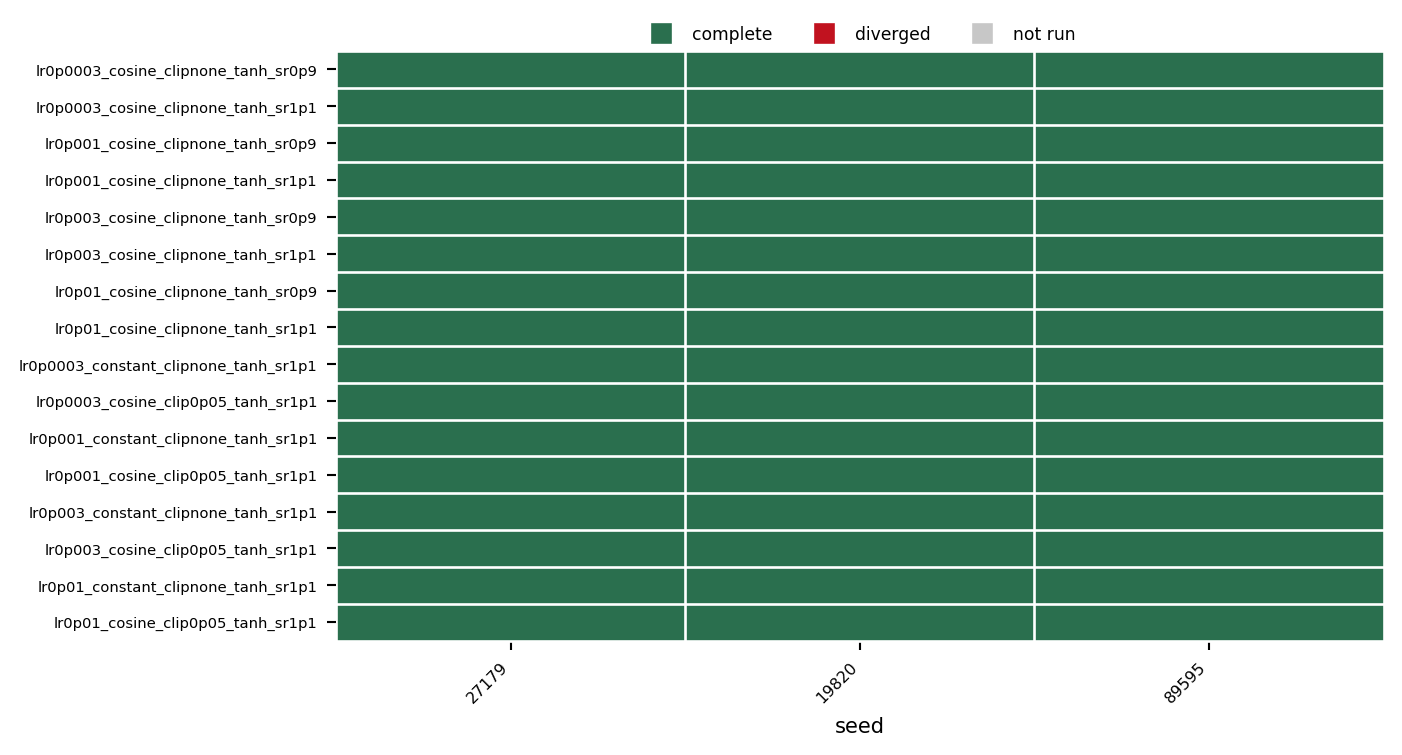

In [15]:
if len(inventory):
    show(viz.plot_sweep_state(inventory), "fig05_sweep_state")

## 6. Result and selection

This section is inert until the sweep finishes. It applies the Section 4a bar to every
seed, then to every configuration, and freezes the winner to
`selected_protocol.yaml` — the file every downstream task imports, so the recipe is
recorded once rather than restated in each notebook.

In [16]:
results = protocol.configurations_meeting_bar(inventory, BAR)
finished = results[results["n_complete"] == results["n_seeds"]] if len(results) else results

if len(finished) < 2:
    display(Markdown(
        f"Only **{len(finished)}** of {len(results)} configurations have all their seeds. "
        f"Re-run once the sweep finishes."
    ))
else:
    display(results)
    show(viz.plot_protocol_results(results), "fig06_protocol_results")

,label,lr,lr_schedule,gradient_clip_norm,activation,spectral_radius,n_seeds,n_complete,n_passing,max_late_spikes,max_final_over_best,median_best_loss,passes_bar
0,lr0p001_cosine_clip0p05_tanh_sr1p1,0.0010,cosine,0.05,tanh,1.1,3,3,3,0,1.000045,0.000203,True
1,lr0p0003_cosine_clip0p05_tanh_sr1p1,0.0003,cosine,0.05,tanh,1.1,3,3,3,0,1.000004,0.000432,True
2,lr0p0003_cosine_clipnone_tanh_sr0p9,0.0003,cosine,NaN,tanh,0.9,3,3,3,0,1.000000,0.000525,True
3,lr0p0003_cosine_clipnone_tanh_sr1p1,0.0003,cosine,NaN,tanh,1.1,3,3,3,0,1.000000,0.000525,True
4,lr0p003_cosine_clip0p05_tanh_sr1p1,0.0030,cosine,0.05,tanh,1.1,3,3,1,1,1.000183,0.000134,False
5,lr0p001_cosine_clipnone_tanh_sr0p9,0.0010,cosine,NaN,tanh,0.9,3,3,1,1,1.000484,0.000233,False
6,lr0p001_cosine_clipnone_tanh_sr1p1,0.0010,cosine,NaN,tanh,1.1,3,3,1,1,1.000484,0.000233,False
7,lr0p0003_constant_clipnone_tanh_sr1p1,0.0003,constant,NaN,tanh,1.1,3,3,1,0,1.026297,0.000403,False
8,lr0p001_constant_clipnone_tanh_sr1p1,0.0010,constant,NaN,tanh,1.1,3,3,0,4,4.599872,0.000513,False
9,lr0p003_cosine_clipnone_tanh_sr0p9,0.0030,cosine,NaN,tanh,0.9,3,3,2,1,1.000830,0.001023,False


In [17]:
passing = results[results["passes_bar"]] if len(results) else results
sweep_complete = len(results) > 0 and bool((results["n_complete"] == results["n_seeds"]).all())

if not sweep_complete:
    display(Markdown(
        f"The sweep has not finished — **{int(inventory['complete'].sum())} of {len(inventory)}** cells "
        f"are trained. Selection is deferred until every configuration has all its seeds, because a "
        f"bar that requires *all* seeds to pass cannot be applied to a partial configuration."
    ))
elif len(passing) == 0:
    display(Markdown(
        "**No configuration clears the bar.** That is itself the result, and the next step is "
        "the monotone guard: because the objective is deterministic "
        "(Section 2a), a step that raises the loss can simply be rejected and retaken at half the "
        "step size. That makes a monotone trajectory a guarantee rather than a tuning outcome, at a "
        "cost of roughly one extra forward pass per iteration."
    ))
else:
    winner = passing.sort_values("median_best_loss").iloc[0]
    selected_path = protocol.write_selected_protocol(
        passing.sort_values("median_best_loss").rename(columns={"passes_bar": "passes"}),
        configs,
        path=TASK_ROOT / "selected_protocol.yaml",
        epochs=SWEEP_EPOCHS,
    )
    display(Markdown(
        f"**{len(passing)} of {len(results)} configurations clear the bar.** The selected recipe is "
        f"**`{winner['label']}`** — learning rate {winner['lr']:g}, {winner['lr_schedule']} schedule, "
        f"clip {winner['gradient_clip_norm']}, {winner['activation']}, spectral radius "
        f"{winner['spectral_radius']:g} — with median best loss {winner['median_best_loss']:.3g}, "
        f"worst final-over-best {winner['max_final_over_best']:.4f} and no late spikes on any seed.\n\n"
        f"Frozen to `{selected_path}`."
    ))

**4 of 16 configurations clear the bar.** The selected recipe is **`lr0p001_cosine_clip0p05_tanh_sr1p1`** — learning rate 0.001, cosine schedule, clip 0.05, tanh, spectral radius 1.1 — with median best loss 0.000203, worst final-over-best 1.0000 and no late spikes on any seed.

Frozen to `/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/chapter/00_training_protocol/selected_protocol.yaml`.

## 7. Does a good loss mean a faithful trace?

Selection in Section 6 is made on the training loss, which is a weighted sum of a
pointwise term and two temporal-difference terms. It is not on a scale anyone can read,
and it is not the quantity any downstream claim rests on. Two checks before the recipe is
accepted:

1. **Quantitatively** — $R^2$ against the observed trajectories, in region PC space *and*
   in PC-backprojected firing-rate space. The two can disagree: the PC target weights all
   42 components equally, while firing-rate space is dominated by the high-variance ones,
   so a model that loses the small PCs looks bad on one and perfect on the other.
2. **Visually** — the traces themselves, for the **three best-fitting runs**. A model can
   drive the derivative and curvature terms down by smoothing transients into a slow
   drift, which costs little loss and destroys exactly the dynamics the modelling is
   about. Only a trace plot shows that.

The firing-rate target is the observed PC scores back-projected into rate space, not the
raw recorded rate: the 42-component truncation discards variance the model was never
asked to reproduce, and scoring against the raw rate would charge it for that.

,label,seed,best_loss,final_over_best
0,lr0p003_cosine_clip0p05_tanh_sr1p1,895953307,0.000129,1.000183
1,lr0p003_cosine_clip0p05_tanh_sr1p1,271795885,0.000134,1.000183
2,lr0p003_cosine_clip0p05_tanh_sr1p1,1982049089,0.000140,1.000000


median             min        
space       fr      pc      fr      pc
region                                
accg    0.9998  0.9939  0.9996  0.9676
bla     0.9999  0.9978  0.9999  0.9902
dmpfc   0.9998  0.9944  0.9996  0.9747
ofc     0.9999  0.9953  0.9997  0.9814

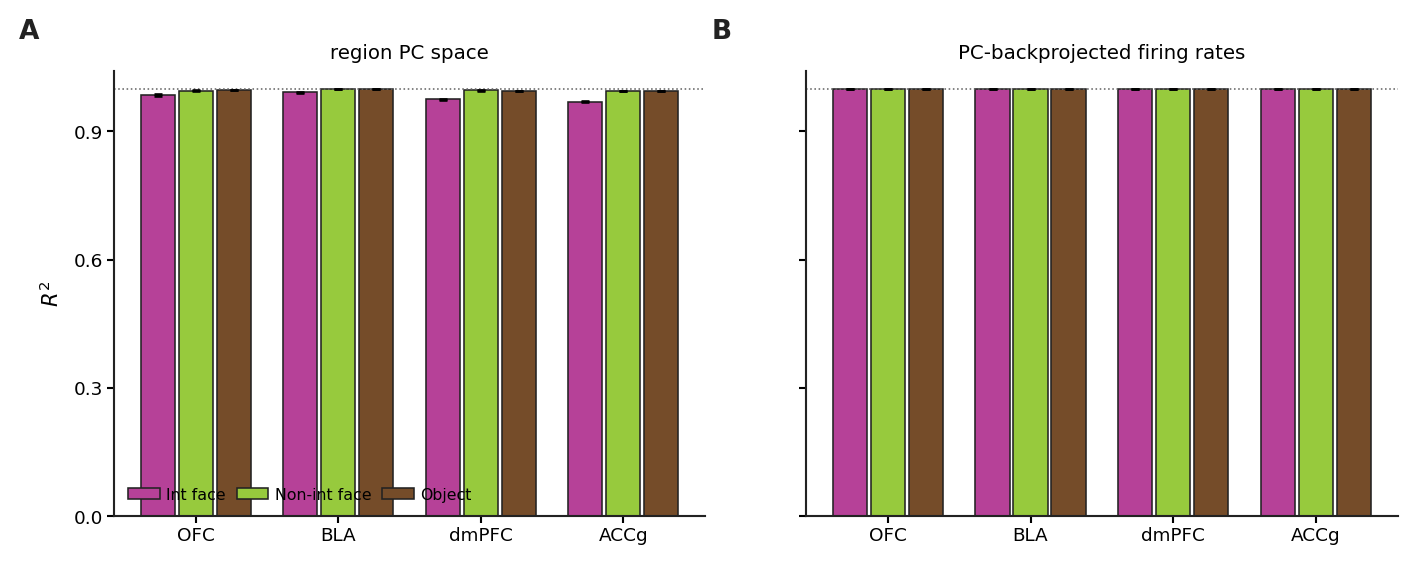

In [18]:
top_runs = protocol.rank_runs_by_loss(inventory, top_n=3)

if len(top_runs) == 0:
    display(Markdown("No completed runs yet — this section fills in as the sweep lands."))
else:
    display(top_runs[["label", "seed", "best_loss", "final_over_best"]].round(6))
    top_quality = protocol.collect_reconstruction_quality(
        inventory[inventory["run_dir"].isin(top_runs["run_dir"])]
    )
    display(
        top_quality.groupby(["space", "region"])["r2"]
        .agg(["median", "min"])
        .unstack("space")
        .round(4)
    )
    show(viz.plot_reconstruction_quality(top_quality), "fig07_reconstruction_quality")

In [19]:
if len(top_runs):
    worst_cell = top_quality[top_quality["space"] == "pc"].nsmallest(1, "r2").iloc[0]
    by_condition = top_quality[top_quality["space"] == "pc"].groupby("condition")["r2"].median()
    display(Markdown(
        f"Across the top {len(top_runs)} runs, median PC $R^2$ is "
        f"**{top_quality.loc[top_quality['space'] == 'pc', 'r2'].median():.3f}** and median "
        f"firing-rate $R^2$ is **{top_quality.loc[top_quality['space'] == 'fr', 'r2'].median():.4f}**. "
        f"The gap between the two spaces is the 42-PC truncation: rate space is carried by the "
        f"leading components, so it flatters the fit.\n\n"
        f"By condition, median PC $R^2$ is "
        + ", ".join(f"**{c.replace('_', ' ')}** {v:.3f}" for c, v in by_condition.items())
        + f". The worst single cell is **{worst_cell['region']} / "
        f"{worst_cell['condition'].replace('_', ' ')}** at $R^2$ = {worst_cell['r2']:.3f}."
    ))

Across the top 3 runs, median PC $R^2$ is **0.994** and median firing-rate $R^2$ is **0.9998**. The gap between the two spaces is the 42-PC truncation: rate space is carried by the leading components, so it flatters the fit.

By condition, median PC $R^2$ is **face interactive** 0.979, **face non interactive** 0.995, **object** 0.996. The worst single cell is **accg / face interactive** at $R^2$ = 0.968.

### 7a. The traces

Coloured solid lines are observed, dark dashed are the model. The PC panel shows the
leading three components per region, with later components faded.

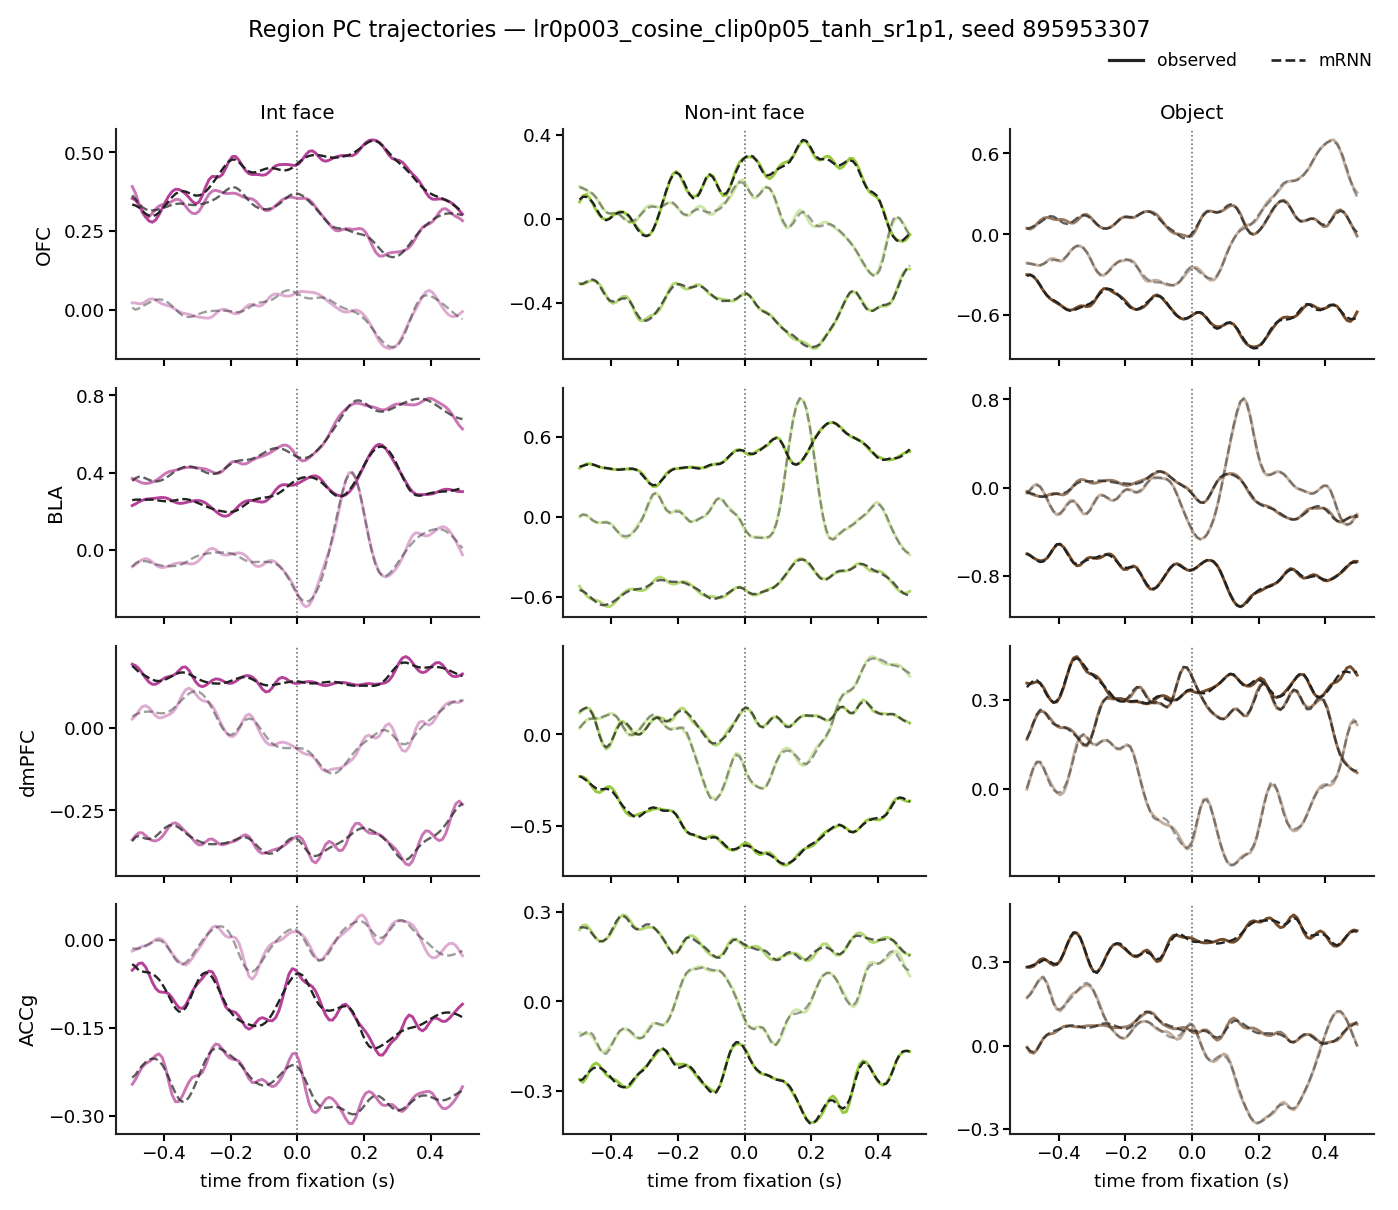

In [20]:
if len(top_runs):
    best_run = top_runs.iloc[0]
    pc_traces = protocol.extract_pc_traces(best_run["run_dir"], n_components=3)
    show(
        viz.plot_pc_trace_overlay(
            pc_traces,
            title=f"Region PC trajectories — {best_run['label']}, seed {best_run['seed']}",
        ),
        "fig08_pc_traces",
    )

The firing-rate panels below show the **median-** and **worst-fitting unit** in each
region, not the best. Showing the best would make this decoration; the question is what
the failure mode looks like when there is one.

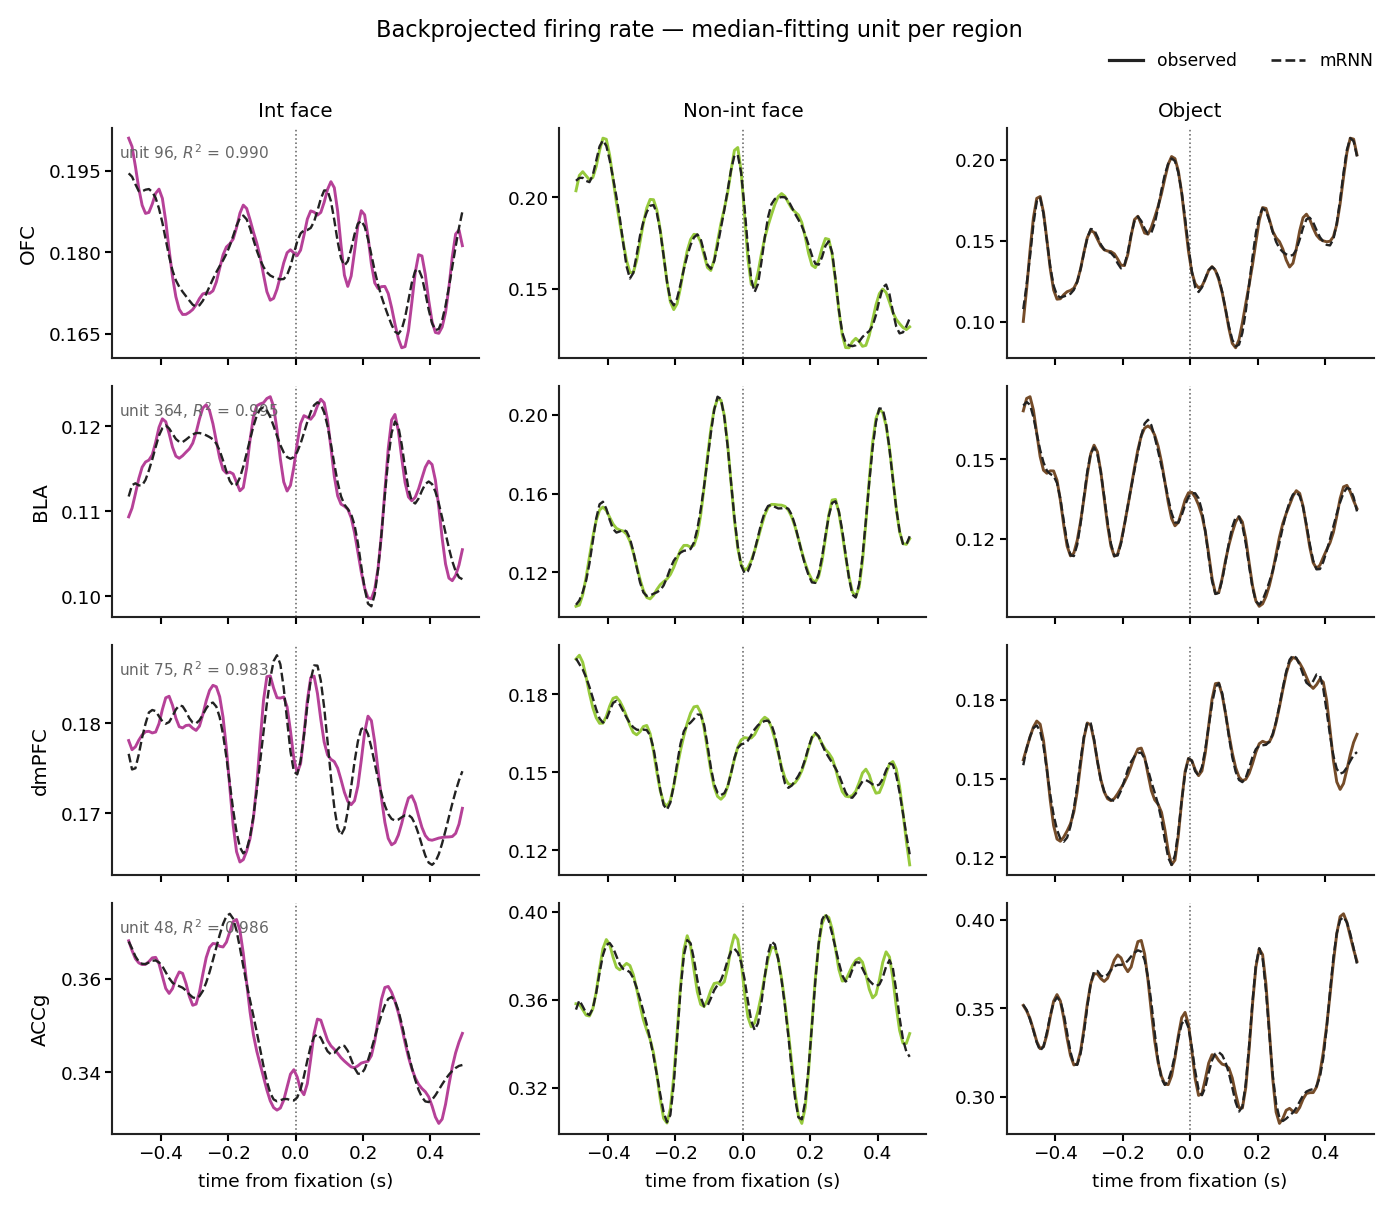

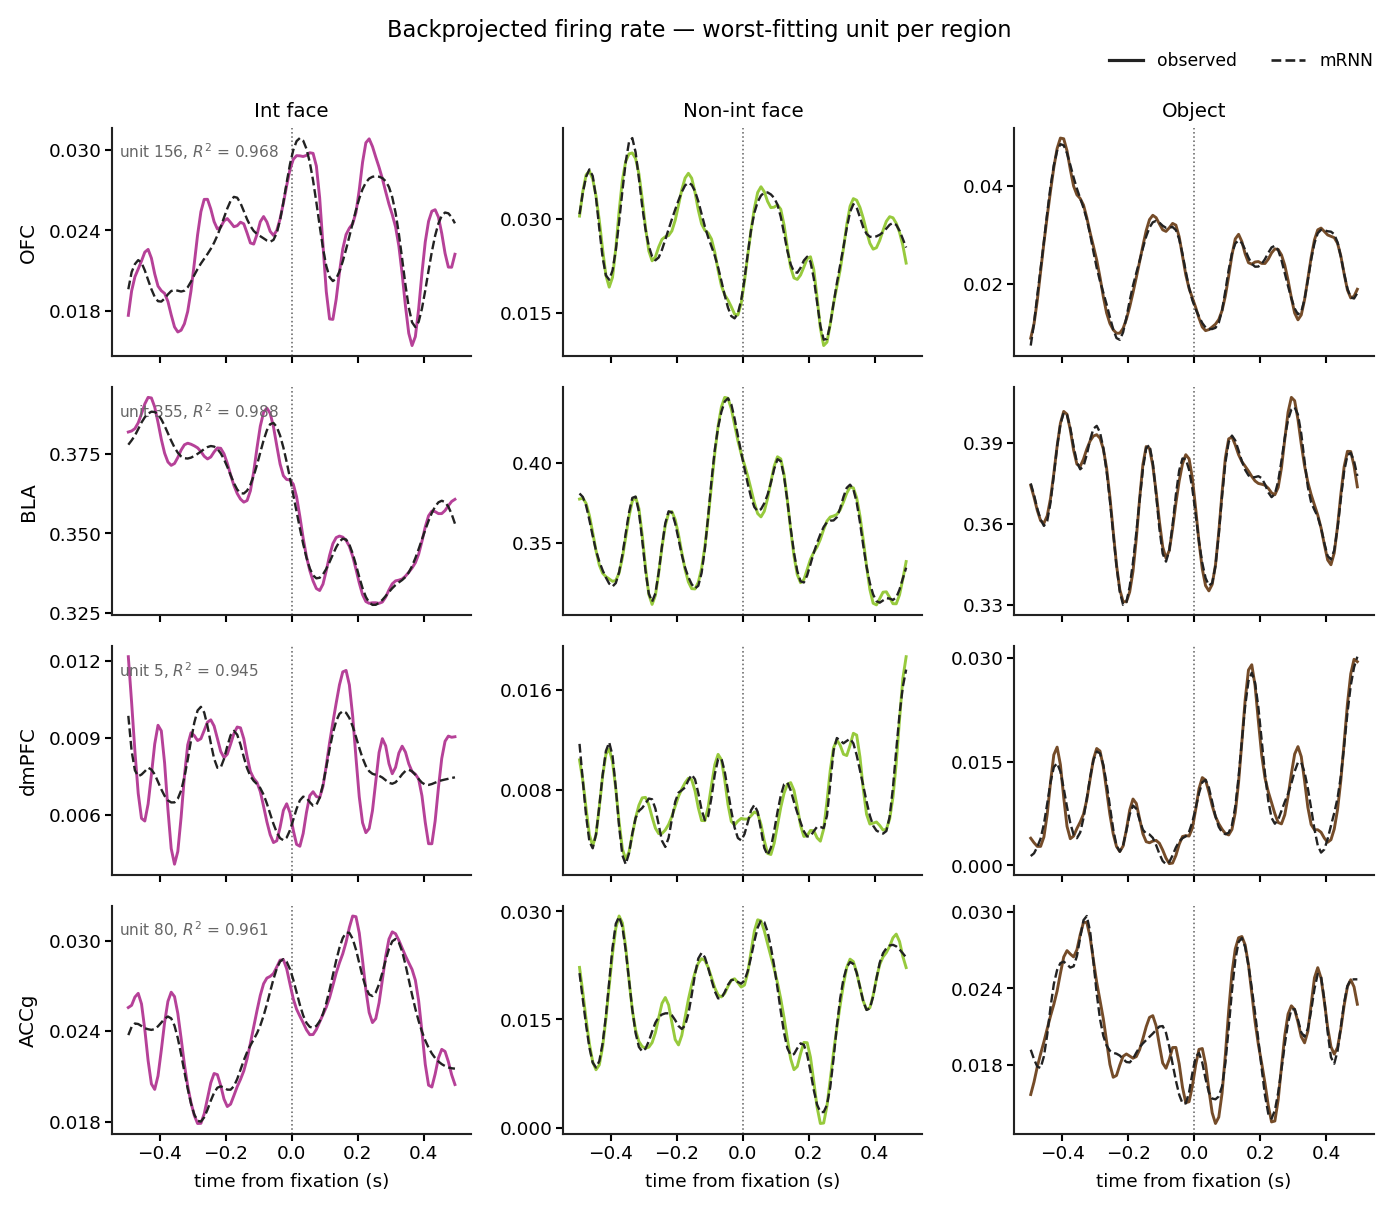

In [21]:
if len(top_runs):
    for rank, stem in (("median", "fig09_fr_traces_median"), ("worst", "fig10_fr_traces_worst")):
        traces = protocol.extract_firing_rate_traces(best_run["run_dir"], unit_rank=rank)
        show(viz.plot_firing_rate_trace_overlay(traces), stem)

### 7b. Is the loss a usable proxy for reconstruction?

Selecting on the loss is only legitimate if the runs the loss prefers are also the runs
that reconstruct best. That is a claim about *these* fits, not a general truth, so it is
worth scattering rather than assuming.

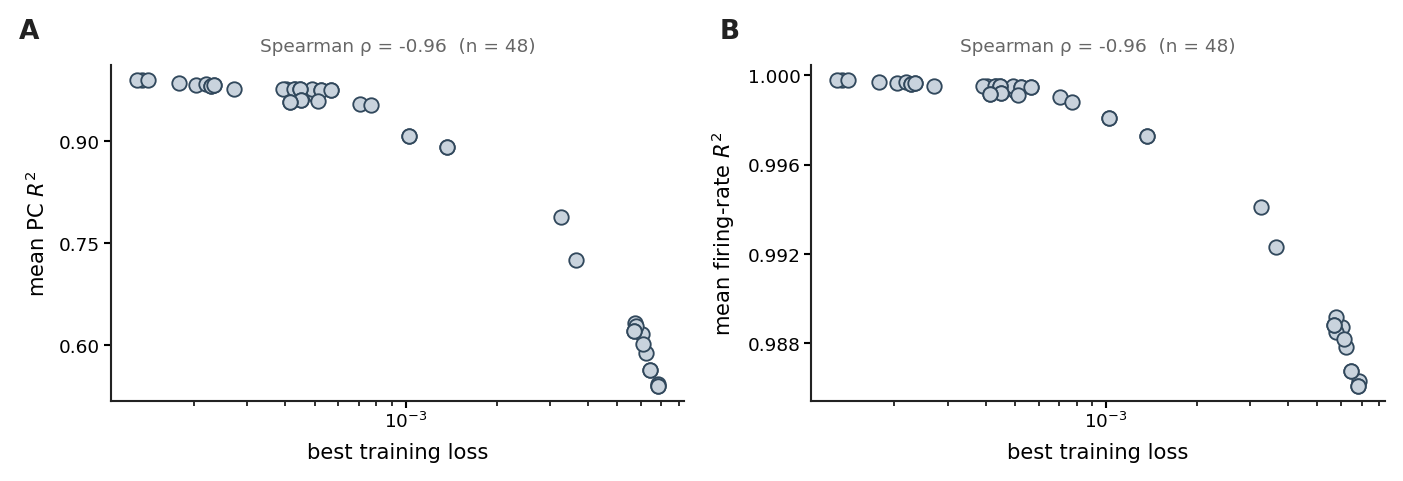

,label,seed,mean_fr_r2,mean_pc_r2,best_loss,final_over_best
28,lr0p003_cosine_clip0p05_tanh_sr1p1,895953307,0.99980,0.99052,0.00013,1.00018
27,lr0p003_cosine_clip0p05_tanh_sr1p1,271795885,0.99979,0.98985,0.00013,1.00018
29,lr0p003_cosine_clip0p05_tanh_sr1p1,1982049089,0.99981,0.99081,0.00014,1.00000
16,lr0p001_cosine_clip0p05_tanh_sr1p1,895953307,0.99970,0.98541,0.00018,1.00003
15,lr0p001_cosine_clip0p05_tanh_sr1p1,271795885,0.99966,0.98343,0.00020,1.00005
17,lr0p001_cosine_clip0p05_tanh_sr1p1,1982049089,0.99969,0.98492,0.00022,1.00001
19,lr0p001_cosine_clipnone_tanh_sr0p9,895953307,0.99962,0.98166,0.00023,1.00001
22,lr0p001_cosine_clipnone_tanh_sr1p1,895953307,0.99962,0.98166,0.00023,1.00001
23,lr0p001_cosine_clipnone_tanh_sr1p1,1982049089,0.99964,0.98272,0.00023,1.00004
20,lr0p001_cosine_clipnone_tanh_sr0p9,1982049089,0.99964,0.98272,0.00023,1.00004


In [22]:
if int(inventory["complete"].sum()) >= 4:
    all_quality = protocol.collect_reconstruction_quality(inventory)
    comparison = protocol.loss_versus_reconstruction(
        all_quality, protocol.rank_runs_by_loss(inventory, top_n=len(inventory))
    )
    show(viz.plot_loss_versus_reconstruction(comparison), "fig11_loss_vs_reconstruction")
    display(comparison.sort_values("best_loss").round(5).head(10))
else:
    display(Markdown("Needs at least four completed runs; re-run once more of the sweep has landed."))

## 8. What this settles, and what comes next

**Settled, once the sweep completes.** The training recipe: learning rate, schedule,
clipping, activation and initial spectral radius, chosen against a bar fixed in advance
and recorded in one file that every later task reads.

**Reportable in its own right.** Three of these are results, not housekeeping:

1. The objective is deterministic, so the spikes were the optimiser overshooting, not noise.
2. Gradient clipping as configured never bound — the threshold sat 40× above the typical
   gradient. Both the legacy tree and the seed-matched pilot agree it did nothing.
3. A decaying learning rate makes the final iterate the best iterate on every seed. The
   cost is a worse best loss at a fixed peak rate, which is why the peak has to be swept
   rather than assumed.
4. A converged loss is not the same as a faithful trace, and Section 7 is where the two
   are checked against each other rather than assumed to agree.

**Still open after this notebook.**

- Whether stable fitting changes the seed-to-seed disagreement in inter-regional currents.
  That is the point of the whole exercise and it is answered in task 05, not here.
- The target and loss themselves: 42 PCs or fewer, flat or variance-weighted, and the
  derivative and curvature weights. Task 01.
- Whether the selected recipe holds at the longer iteration budgets the ensembles need.
  The finalists should be confirmed at full length with more seeds before task 02 starts.

**Next:** `01_target_and_loss.ipynb`.